In [5]:
# ==========================================
# STEP 1: INITIALIZATION & DATA CLEANING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import datetime as dt

# Load your dataset (Replace with your actual file path)
# Expected columns: CustomerID, TransactionDate, TransactionID, Amount
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")

print("--- Initial Data Info ---")
print(df.info())

# 1. Drop missing Customer IDs
df = df.dropna(subset=['Customer ID'])

# 2. Fix data types
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])
df['Customer ID'] = df['Customer ID'].astype(int)

# 3. Handle anomalies (Filter out negative or zero transaction amounts)
df = df[df['Product Price'] > 0]

print(f"\nCleaned Data Shape: {df.shape}")

--- Initial Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB
None


In [10]:
# ==========================================
# STEP 2: RFM FEATURE ENGINEERING
# ==========================================
# Set "snapshot date" as one day after the most recent transaction in the data
snapshot_date = df['Purchase Date'].max() + dt.timedelta(days=1)

# Aggregate transaction data at the customer level
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date - x.max()).days, # Recency
    'Product Category': 'count',                                   # Frequency
    'Product Price': 'sum'                                             # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']
print("\n--- RFM Base Table Sample ---")
print(rfm.head())


--- RFM Base Table Sample ---
   Customer ID  Recency  Frequency  Monetary
0            1       58          1       169
1            2      299          3       420
2            3       89          8      1803
3            4      127          4       537
4            5      171          8      1832


In [12]:
# ==========================================
# STEP 3: SEGMENTATION VIA K-MEANS CLUSTERING
# ==========================================
# Log transform to eliminate skewness, then scale features
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Fit K-Means (Using 4 clusters for distinct, actionable personas)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Map numeric clusters to meaningful, strategic business names
# (Inspect your cluster averages to precisely tailor these labels)
cluster_map = {
    0: "Champions / Loyal",
    1: "At Risk / Churn Risk",
    2: "New / Recent Customers",
    3: "Hibernating / Low Value"
}
rfm['Segment'] = rfm['Cluster'].map(cluster_map)

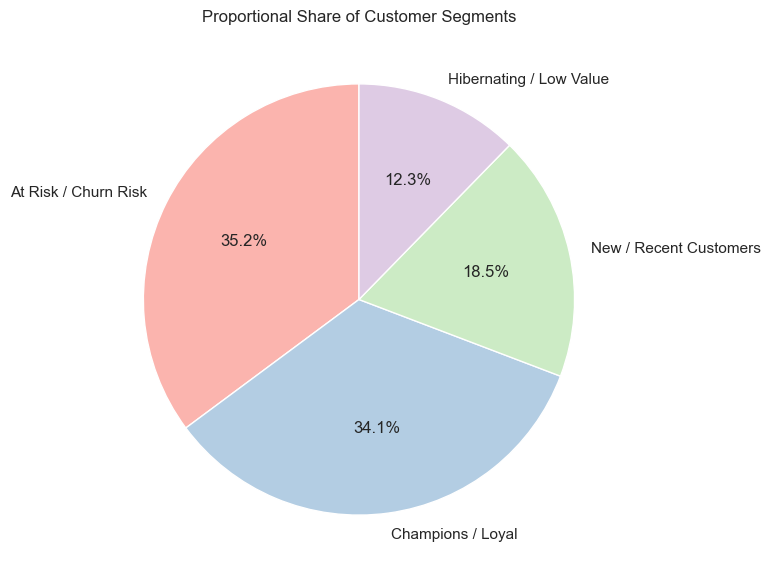


--- Aggregated Profiling Metrics ---
                            Recency  Frequency     Monetary
Segment                                                    
At Risk / Churn Risk     338.944002   3.863040   955.594618
Champions / Loyal        213.120780   6.927461  1833.315460
Hibernating / Low Value  521.857867   1.883873   380.496402
New / Recent Customers    29.472601   5.865127  1485.840723


In [16]:
# ==========================================
# STEP 4: VISUALIZATION & RETENTION ANALYSIS
# ==========================================
sns.set_theme(style="whitegrid")

# Visualization : Segment Distribution Pie Chart
plt.figure(figsize=(7, 7))
rfm['Segment'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('Pastel1'), startangle=90)
plt.title('Proportional Share of Customer Segments')
plt.ylabel('')
plt.show()

# Save final aggregated dataset for reference
rfm.to_csv("customer_segments_summary.csv", index=False)
print("\n--- Aggregated Profiling Metrics ---")
print(rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean())